In [1]:
# Decision Tree and Random Forest


In [5]:
# import necessary libraries
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier , plot_tree
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [6]:
# import dataset of breast cancer from sklearn
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()

# create X and Y
X = data.data
y = data.target
# split into train and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
# Fit the decision tree model
dt_model = DecisionTreeClassifier(random_state=42)  # random state for reproducibility
dt_model.fit(X_train, y_train)

# Accuracy on train data
y_train_pred = dt_model.predict(X_train)
print("Decision Tree Train Accuracy:", accuracy_score(y_train, y_train_pred))

Decision Tree Train Accuracy: 1.0


In [8]:
# Predict on test set and check accuracy
y_pred = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


Decision Tree Accuracy: 0.9473684210526315
[[40  3]
 [ 3 68]]


In [ ]:
# checking the feature importance of the features
feature_importances = pd.Series(dt_model.feature_importances_, index=data.feature_names)
feature_importances.sort_values(ascending=False, inplace=True)
print("Feature Importances:")
print(feature_importances)

Feature Importances:
mean concave points        0.691420
worst concave points       0.065651
mean texture               0.058478
worst radius               0.052299
worst perimeter            0.051494
fractal dimension error    0.018554
worst texture              0.017445
concave points error       0.015931
area error                 0.011983
worst smoothness           0.009233
concavity error            0.006276
smoothness error           0.001237
mean perimeter             0.000000
mean area                  0.000000
perimeter error            0.000000
texture error              0.000000
radius error               0.000000
mean fractal dimension     0.000000
mean concavity             0.000000
mean symmetry              0.000000
mean smoothness            0.000000
mean compactness           0.000000
mean radius                0.000000
compactness error          0.000000
symmetry error             0.000000
worst area                 0.000000
worst compactness          0.000000
worst c

Note: you may need to restart the kernel to use updated packages.


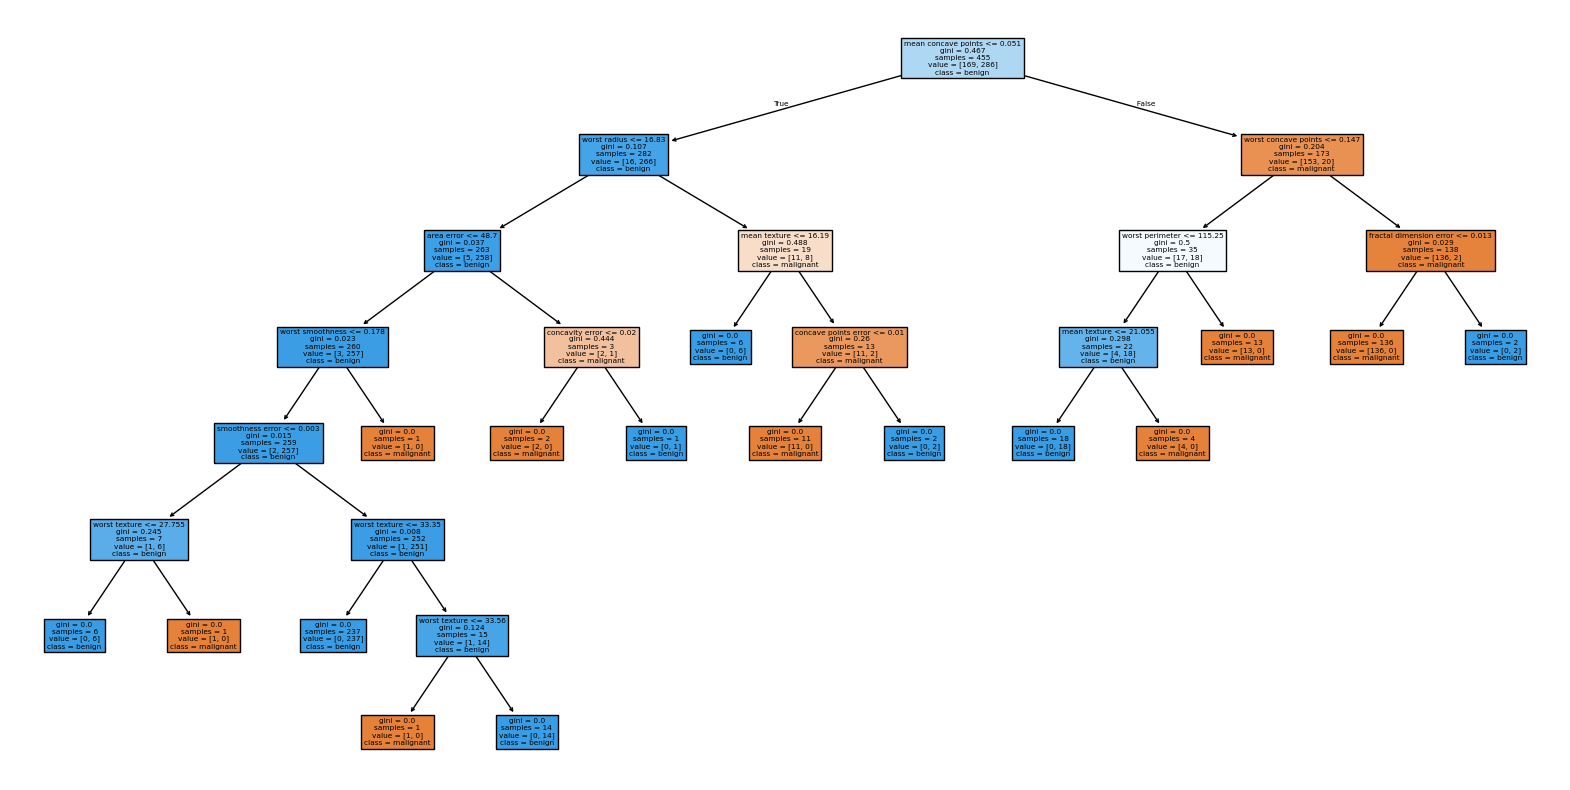

In [9]:
%pip install matplotlib

# plot the tree
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(dt_model, filled=True, feature_names=data.feature_names, class_names=data.target_names)
plt.show()


In [ ]:
# Assignment - fit a random forest model and compare results with decision tree.
rf_model = RandomForestClassifier(random_state=42,n_estimators=12, max_depth=3)  # random state for reproducibility
# these are hyperparameters of the random forest model. You can change them and see how it affects the results.
rf_model.fit(X_train, y_train)
y_rf_pred = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_rf_pred))
print(confusion_matrix(y_test, y_rf_pred))


Random Forest Accuracy: 0.9649122807017544
[[40  3]
 [ 1 70]]


In [17]:
# check the number of trees in the random forest
print("Number of trees in the random forest:", len(rf_model.estimators_))


Number of trees in the random forest: 50


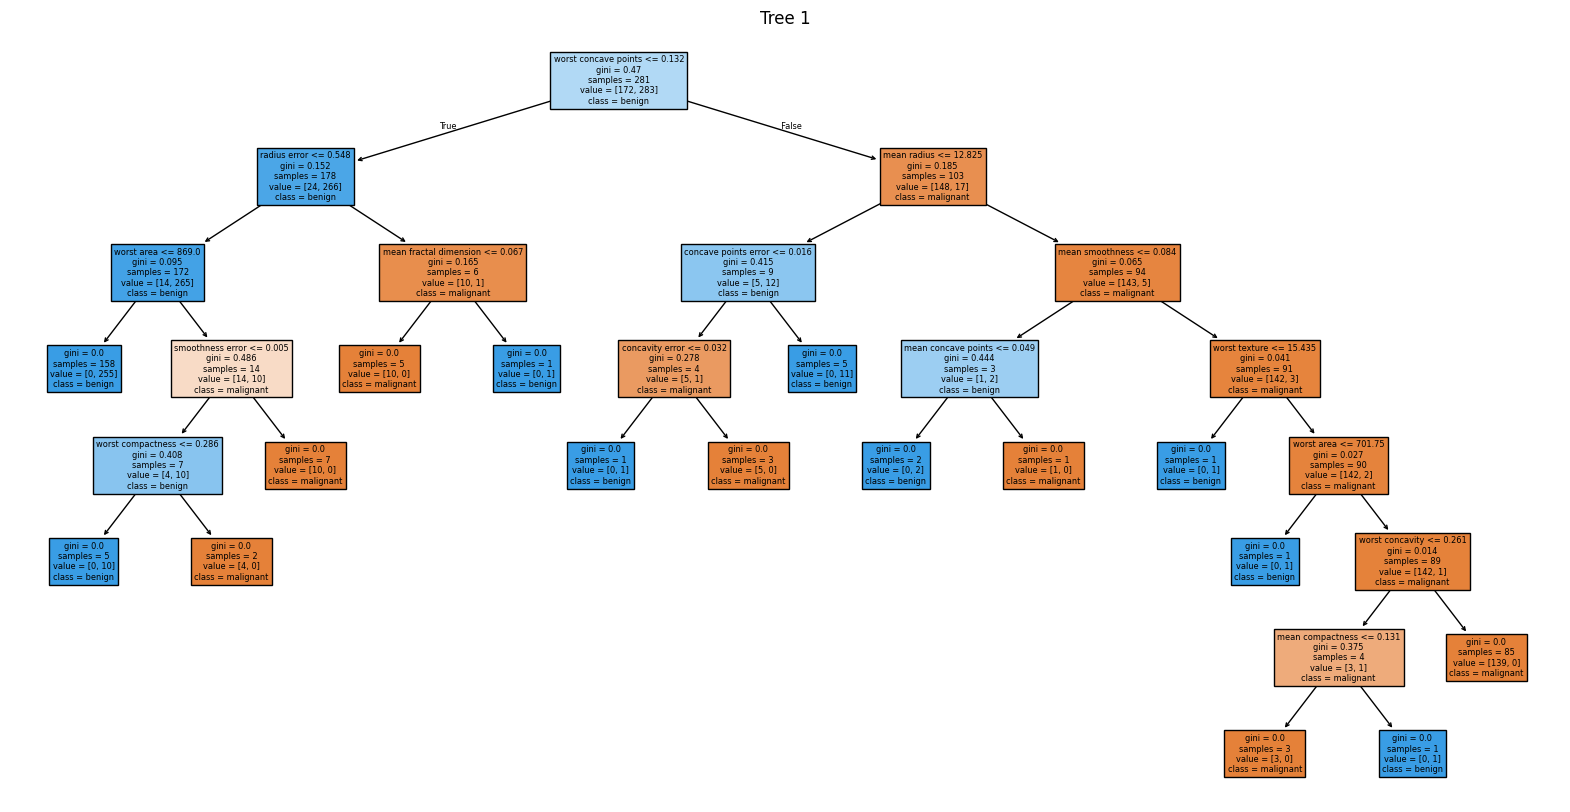

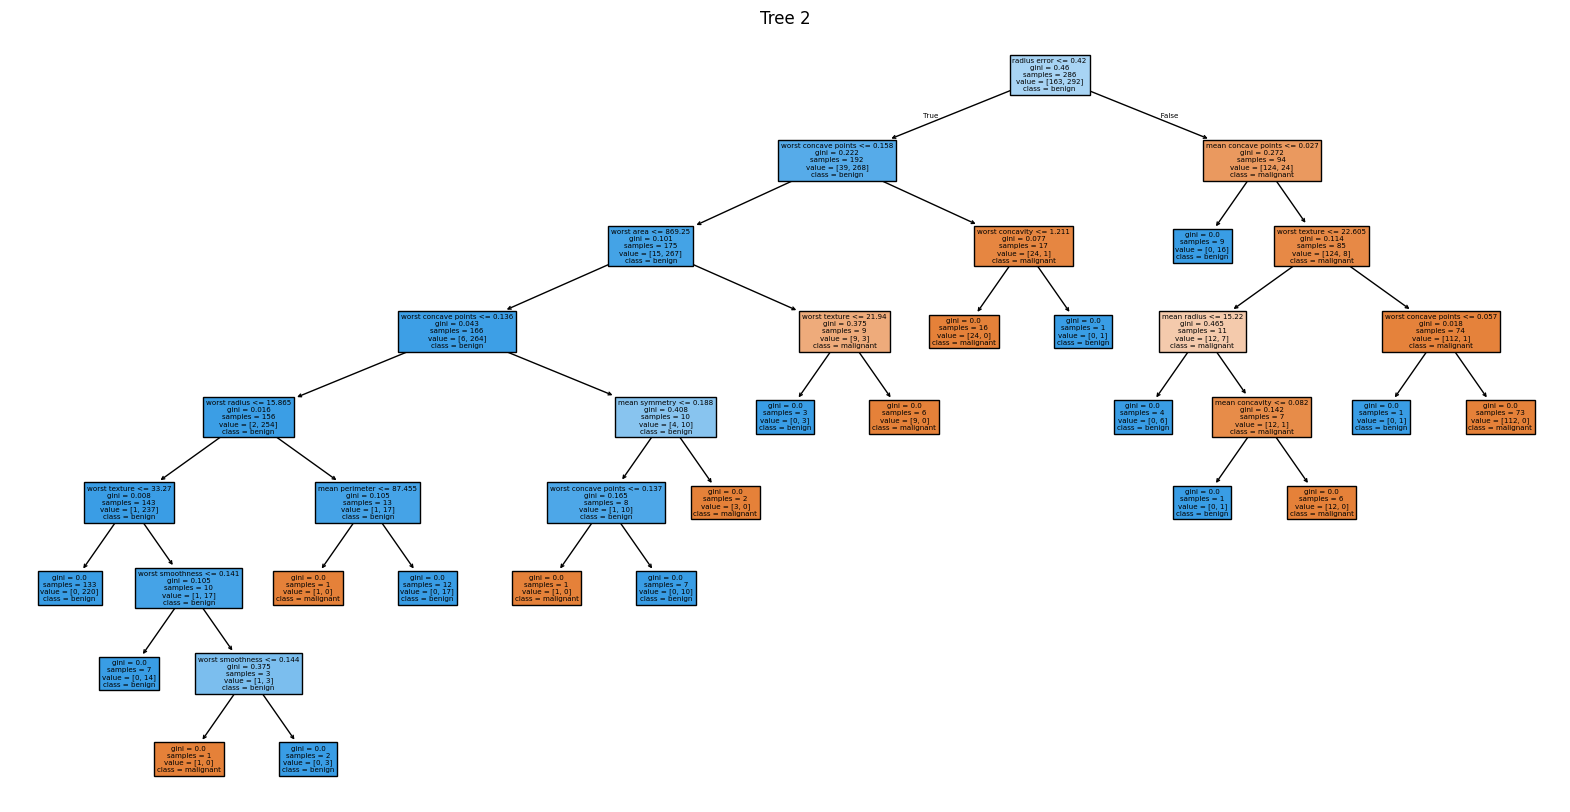

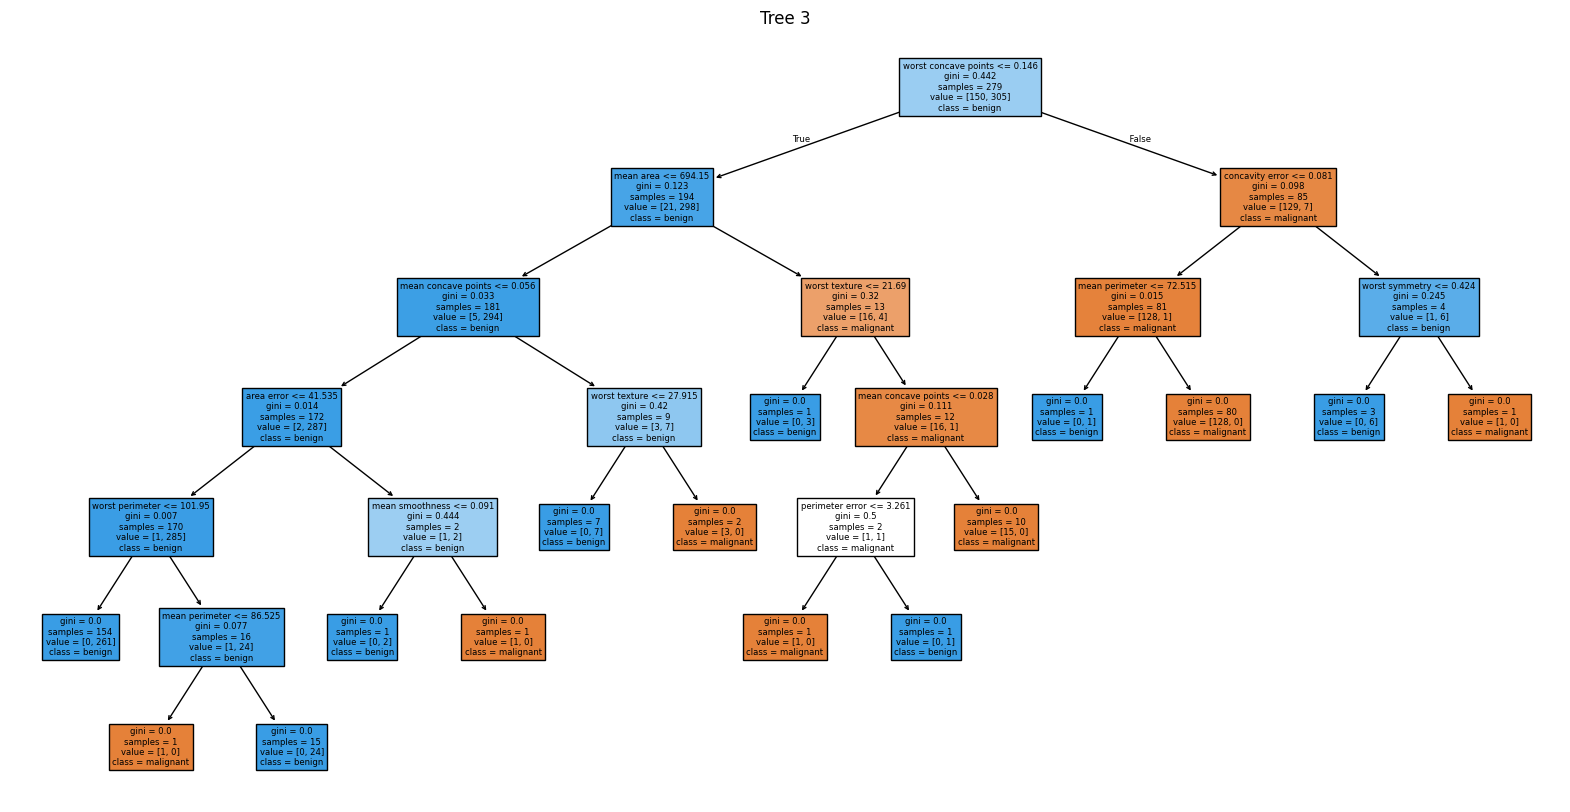

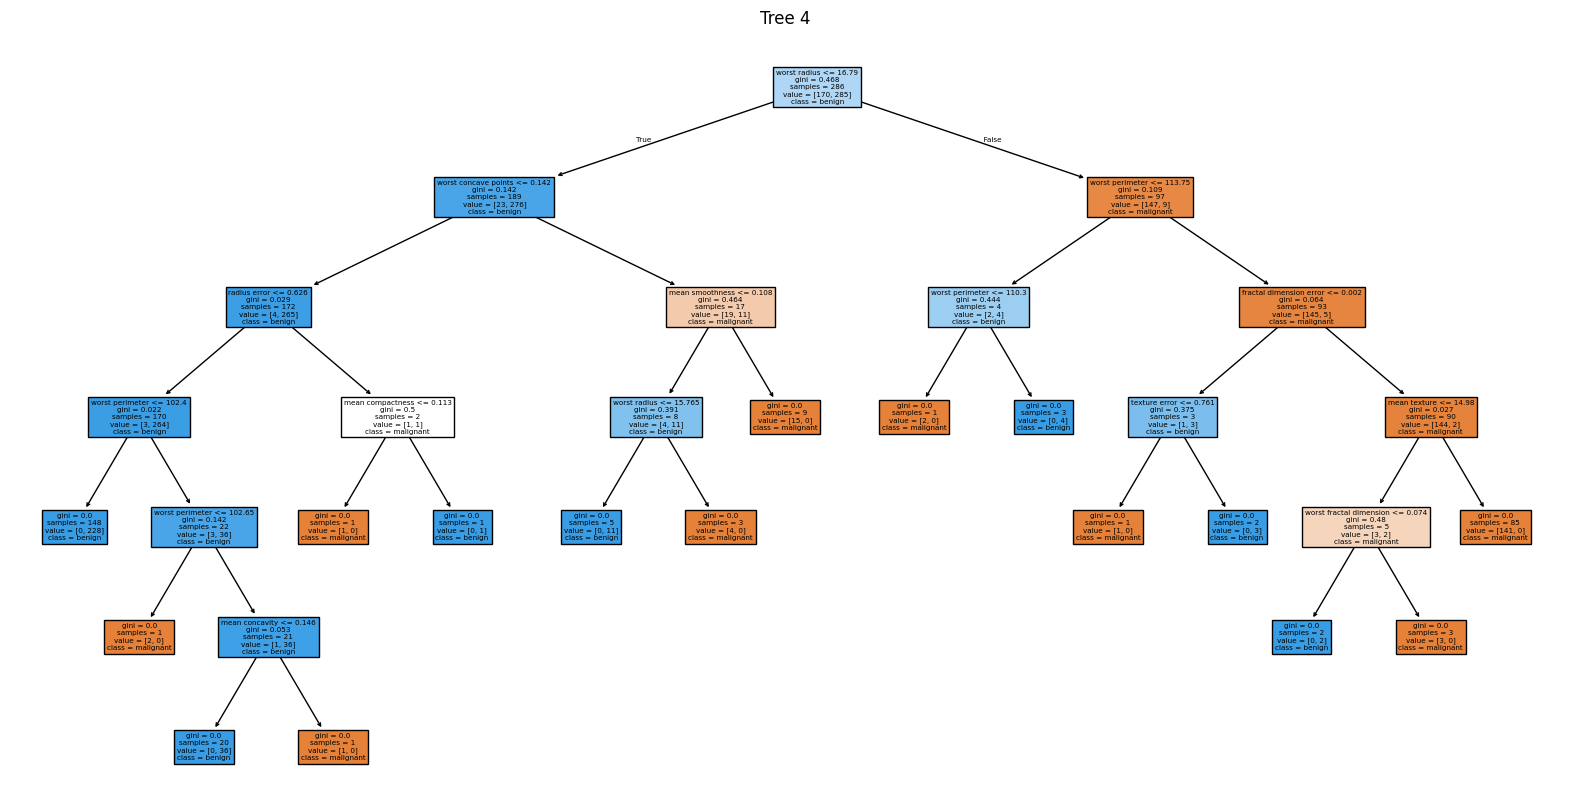

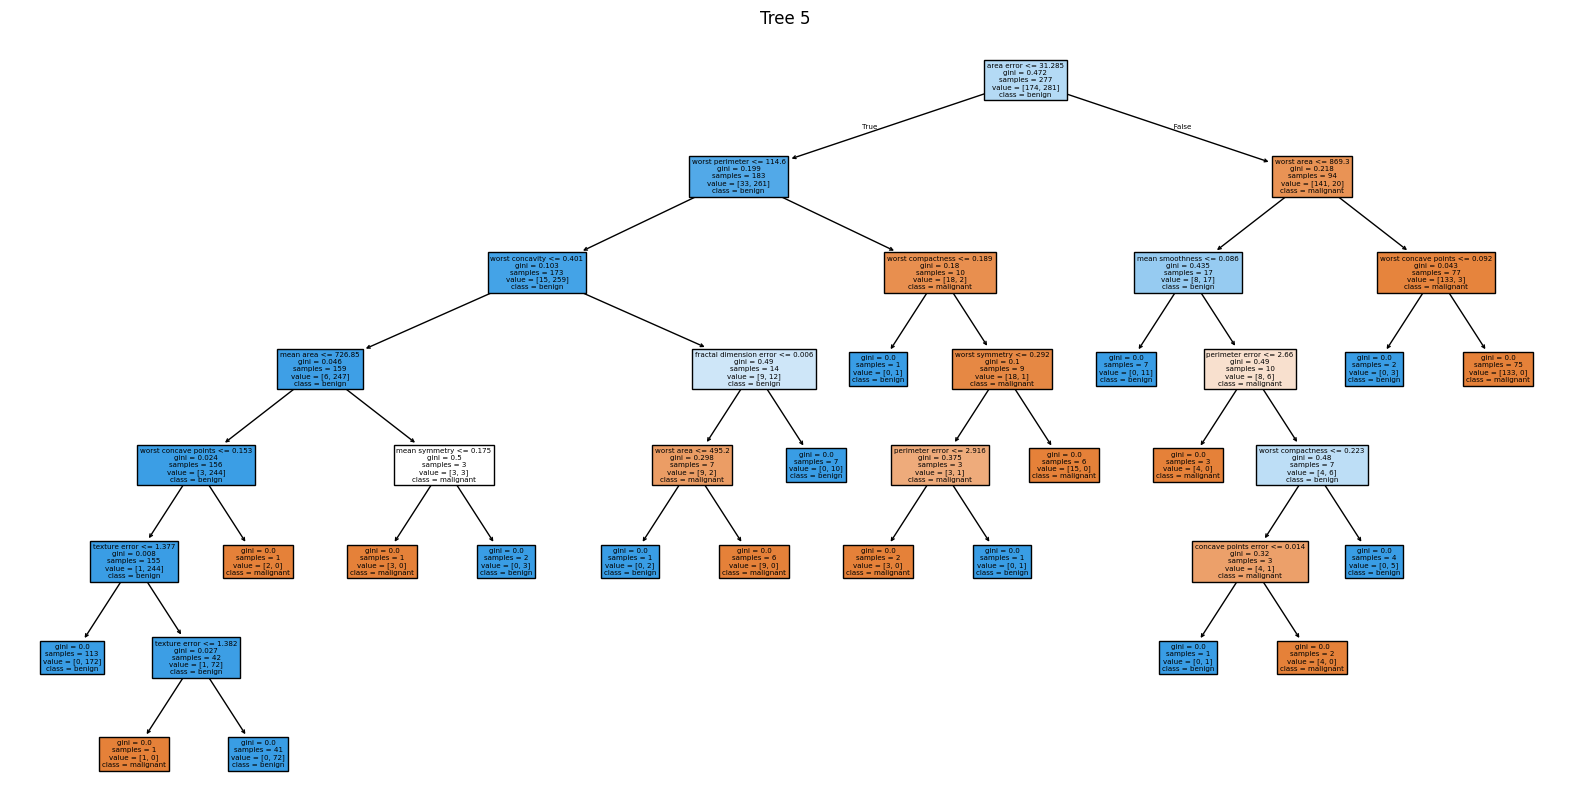

In [12]:
# plot 5 trees from the random forest
for i in range(5):
    plt.figure(figsize=(20,10))
    plot_tree(rf_model.estimators_[i], filled=True, feature_names=data.feature_names, class_names=data.target_names)
    plt.title(f"Tree {i+1}")
    plt.show()